Final Exam 

Exam Number: 75 

Basecamp 2023

In [124]:
#imports
import pandas as pd
import requests as rq
from bs4 import BeautifulSoup
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
import numpy as np
import statsmodels.api as sm

# Data Collection

## Collecting Data from chosen API: Wikipedia

In [125]:
#Importing the Wikipedia API
import wikipediaapi

In [126]:
#Creating User Agent as noted in the Wiki documentation
user_agent = 'student (kgs879@alumni.ku.dk)'
wiki_wiki = wikipediaapi.Wikipedia(user_agent, 'en')

In [127]:
#Creating a list of all the winners of Ru Paul's Drag Race
winners = ['BeBe Zahara Benet','Tyra Sanchez', 'Raja Gemini', 'Sharon Needles', 'Jinkx Monsoon',
           'Bianca Del Rio','Violet Chachki','Bob the Drag Queen','Sasha Velour', 'Aquaria (drag queen)',
          'Yvie Oddly', 'Jaida Essence Hall','Symone (drag queen)','Willow Pill','Sasha Colby']

In [128]:
#initializing lists to store information from the API
title = []
summary = []
num_language = []
language = []
categories = []
full_text = []

In [129]:
#Looping through each Drag Queen in the list
for queen in tqdm(winners):
    #initalzing the wiki page for the specific drag queen
    drag_page = wiki_wiki.page(queen)
    
    #Grabbing the title of the page
    title.append(drag_page.title)
    
    #Grabbing the number of languages other than English 
    num_language.append(len(drag_page.langlinks))
    
    #Grabbing the languages 
    language.append(list(drag_page.langlinks.keys()))
    
    #Grabbing the summary section 
    summary.append(drag_page.summary)
    
    #Grabbing the categories 
    #Making sure just the categories information is used and that it is lowercase
    cat_list = list(drag_page.categories.keys())
    categories.append([cat.replace('Category:', '').lower() for cat in cat_list])
    cat_list = []
    
    #Gathering the full text of the page
    full_text.append(drag_page.text)
    

100%|███████████████████████████████████████████| 15/15 [00:14<00:00,  1.04it/s]


In [130]:
#Function to clean the text by making all the text lowercase and removing punctuations
#Where list_to_clean is a list
def clean_text(list_to_clean): 
    #Creating a list of the characters I want removed from the text
    things_to_remove = [ '(' , ')' , '/' , '"', '\\', '\'', ',', '\n', '.' ] 
    
    #Making sure every word is lowercase
    cleaned = [x.lower() for x in list_to_clean]
    
    #Looping through each unwanted character 
    for remove_item in things_to_remove:
        #Using list comprehension to loop though each text and replace the unwated character with ''
        cleaned = [text.replace(remove_item, '') for text in cleaned]
    
    #Looping through each text and replacing '-' with a space because normally '-' seperates two words
    cleaned = [text.replace('-', ' ') for text in cleaned]

    #returning the now cleaned list
    return cleaned

In [131]:
#Applying the cleaning function to the summary varaible and the full_text variable

summary = clean_text(summary)
full_text = clean_text(full_text)

## Creating Data Frame

In [132]:
#Creating the Ru Paul's Drag Race winners dataframe 

winners_df = pd.DataFrame(list(zip(title, summary, full_text, num_language,language,categories)),
                         columns=['Title','Summary','Full_Text','Number_of_Languages','Languages','Categories'])

In [133]:
#Checking data frame
winners_df.head()

,Title,Summary,Full_Text,Number_of_Languages,Languages,Categories
0,BeBe Zahara Benet,nea marshall kudi ngwa born march 20 1980 bett...,nea marshall kudi ngwa born march 20 1980 bett...,9,"[es, fa, fr, he, hu, pt, ru, sv, uk]","[1980 births, 21st-century african-american ma..."
1,Tyra Sanchez,james william ross iv born april 22 1988 is an...,james william ross iv born april 22 1988 is an...,1,[fr],"[1988 births, african-american lgbt people, af..."
2,Raja Gemini,sutan ibrahim karim amrullah [suːtɑn ˈibrahɪm ...,sutan ibrahim karim amrullah [suːtɑn ˈibrahɪm ...,10,"[ar, ca, es, fa, fi, fr, he, id, min, sv]","[1974 births, american lgbt people of asian de..."
3,Sharon Needles,sharon needles born november 28 1981 is the st...,sharon needles born november 28 1981 is the st...,8,"[ar, azb, ca, es, fa, fr, ga, sv]","[1981 births, all articles containing potentia..."
4,Jinkx Monsoon,jerick roman lamar hoffer born september 18 19...,jerick roman lamar hoffer born september 18 19...,12,"[arz, azb, ca, de, es, fa, fi, fr, he, it, pt,...","[1987 births, 21st-century american lgbt peopl..."


## Text Analysis
### Conducting Word Count

In [134]:
#Creating a function to count the number of words in an observation
#Where text is a string
def word_count(text):
    #Splitting the text into words and then counting the amount of words
    return len(text.split())
          

In [135]:
#Applying this function to the summary variable

words = [] #Creating a list of each word count to add to the dataframe

#Looping though each observation in summary
for x in summary:
    #Adding the word count of each summary to the list
    words.append(word_count(x))
    

In [136]:
#Adding the summary word count to the dataframe

winners_df['Summary_Word_Count'] = words

### Most Popular Word in the Summary Variable 

In [137]:
#Creating a most popular word function

def most_pop_word(column):
    #initializing dictionary to story word count
    pop_word = {} 
    
    #creating list of common words to later remove
    common_words = ['the', 'in', 'of', 'and', 'is', 'a', 'on', 'an', 'as','for','to']
    
    for x in column: #looping through each observation
        
        for word in x.split(): #looping through each word
            
            if word not in common_words: #making sure the common words are not in the dictionary
                
                if word in pop_word: #checking if the word is in the dictionary 
                    pop_word[word] += 1 #If the word is in the dictionary add one to the count
                
                else:
                    pop_word[word] = 1 #If it is not in dictionary then the word has a count of 1
    
    #Sorting the dictionary by most popular word            
    sorted_ = sorted(pop_word.items(), key=lambda x:x[1], reverse=True) 
    
    #turning it back into a dictionary to investigate word frequencies
    return dict(sorted_) 
                
        
    

In [138]:
#Applying the function to the summary varaible
pop_word_dict = most_pop_word(summary)

#Printing the first key in the dictionary which is the most used word
print(f'The most popular word in the Summary variable is: {list(pop_word_dict.keys())[0]}')

The most popular word in the Summary variable is: drag


### Most Popular Word Count for Each Observation in the Summary Variable 

As shown by the above code the most popular word is 'drag'. I will count the amount of times it is used in the summary variable. 

In [139]:
#Creating a function that counts how many times a given word is each observation for a chosen varaible

#Arguments are given where column = the chosen column in a df 
#pop_word = the word you want to count as a string 
def pop_word_count(column, pop_word):  
    
    #Initializing list
    word_count_list = []
    
    #Looping through each observation
    for x in column:
        
        #Splitting the observation so that it is a list of words
        words = x.split()
        
        #Checking if the chosen word in the observation
        if pop_word in x:
            #If the word is there coduct a count of the word
            word_count = words.count(pop_word)
            #Append the word count to a list
            word_count_list.append(word_count)
        
        #If the word is not in the observation add 0 to the list
        else:
            word_count_list.append(0)
        
    
    return word_count_list #return the list to add to the df

In [140]:
#Adding the word count of 'drag' in summary variable to a new column
winners_df['drag_count_summary'] = pop_word_count(summary,'drag')

### Conducting Relevant Word Count

In [141]:
#I am unsure what the instructions are asking, but I am going to choose a relavant word 
# and count how many times its used in the full text column. The word I choose is 'winner'.

In [142]:
#Applying the popular word count function to find the number of times winner is used in the full_text column
#And adding it to the df
winners_df['winner_count_full_text'] = pop_word_count(full_text,'winner')

### Most Popular Word in Each Observation for the Summary Variable

In [143]:
#Creating a most popular word function for individual observations for one varaible
#Where column = the chosen column of the df
def pop_word_observation(column):
    
    #initializing list to store the top word for each observation
    pop_word_list = [] 
    #initializing dictionary to store the word frequency for each observation
    pop_word_dict = {} 
    
    #creating list of common words
    common_words = ['the', 'in', 'of', 'and', 'is', 'a', 'on', 'an', 'as','for','to','his','they']
    
    for x in column: #looping through each observation
        
        for word in x.split(): #looping through each word
            
            if word not in common_words: #making sure the common words are not in the dictionary
                
                if word in pop_word_dict: #checking if the word is in the dictionary 
                    pop_word_dict[word] += 1 #If the word is in the dictionary add one to the count
                
                else:
                    pop_word_dict[word] = 1 #If it is not in dictionary then the word has a count of 1
            
         #Sorting the dictionary by most popular word   
        pop_word_dict = dict(sorted(pop_word_dict.items(), key=lambda x:x[1], reverse=True)) 
    
        #Adding the most popular word to a list
        pop_word_list.append(list(pop_word_dict.keys())[0])
        
        #Making the dictionary empty for the next observation
        pop_word_dict = {}
    
    return pop_word_list
                

In [144]:
#Adding the column to the dataframe 
winners_df['top_word_in_summary'] = pop_word_observation(summary)

In [145]:
#Checking the df
winners_df.head()

,Title,Summary,Full_Text,Number_of_Languages,Languages,Categories,Summary_Word_Count,drag_count_summary,winner_count_full_text,top_word_in_summary
0,BeBe Zahara Benet,nea marshall kudi ngwa born march 20 1980 bett...,nea marshall kudi ngwa born march 20 1980 bett...,9,"[es, fa, fr, he, hu, pt, ru, sv, uk]","[1980 births, 21st-century african-american ma...",127,4,3,drag
1,Tyra Sanchez,james william ross iv born april 22 1988 is an...,james william ross iv born april 22 1988 is an...,1,[fr],"[1988 births, african-american lgbt people, af...",118,6,2,drag
2,Raja Gemini,sutan ibrahim karim amrullah [suːtɑn ˈibrahɪm ...,sutan ibrahim karim amrullah [suːtɑn ˈibrahɪm ...,10,"[ar, ca, es, fa, fi, fr, he, id, min, sv]","[1974 births, american lgbt people of asian de...",160,4,2,amrullah
3,Sharon Needles,sharon needles born november 28 1981 is the st...,sharon needles born november 28 1981 is the st...,8,"[ar, azb, ca, es, fa, fr, ga, sv]","[1981 births, all articles containing potentia...",178,4,2,needles
4,Jinkx Monsoon,jerick roman lamar hoffer born september 18 19...,jerick roman lamar hoffer born september 18 19...,12,"[arz, azb, ca, de, es, fa, fi, fr, he, it, pt,...","[1987 births, 21st-century american lgbt peopl...",156,3,2,monsoon


## Saving Data as a CSV File

In [146]:
winners_df.to_csv('Drag_Winners_DF', index=False)

## Reflection and Description of Data

1. The data I collected came from the Wikipedia API. I decided to investigate information about the winners of Ru Paul's Drag Race, a reality TV show about Drag Queens. I collected textual information from the web pages such as the summary and the full text. I also collected the categories of the web page, the title of the page, and the languages available for the web pages translation. I made my own column of counting the number of languages provided. 
2. The process of collected data from the Wikipedia API started with me investigating the documentation. As required I had to create a user agent to be able to access this information. Once created I had to look at the specifics of the API to know how to properly collect the data I wanted. The Wikipedia API is quite straight forward and I did not have any problems accessing the data I needed. 
3. Some ethical considerations that I considered would be the sensitivity of the information that I collected. However, Wikipedia is a public platform so I concluded that this is not a problem. When using the API I also had to consider what is allowed by the API and to make sure to follow the guidelines set by the documentation.
4. When writing my code, one of the decisions I made was to clean the data so that all the words were lower case and to remove special characters. I decided to do this so there was a more accurate representation of what word is the most popular. I also decided to create functions so that I could apply the function to what ever column I decided. This gave me more flexibility with my results and consolidated my code. For variable naming I tried to make sure each variable had a unique name so that it would not get confused in the coding process.   

## Collecting Data using Scraping: pokemondb.net

This website is a database of all the Pokemon that exist and their gaming stats such as HP, Attack, Type, and so on.

In [147]:
#Creating a variable for the url
url = 'https://pokemondb.net/pokedex/all'

#Using requests to get the HTML page 
poke = rq.get(url)
poke.encoding = 'UTF-8' #Making sure the page is in the correct format


In [148]:
#Applying Beatiful Soup 
bs_poke = BeautifulSoup(poke.text, 'html.parser')

### Scraping Pokemon Name


In [149]:
#Creating a list to hold all the names
name_list = []

#Looping through the tag
for name in bs_poke.find_all('a', class_='ent-name'):
    #Adding the name to the list
    name_list.append(name.text)

#Note: It might look like there are duplicates of names. This is because
#one pokemon might have two versions with the same name. For example:
# 'Venusaur' has two rows because one is regular and one is 'mega'.

### Scraping Pokemon Type 

Pokemon each have a type connected to them, sometimes they even have two types. A type would be like a species. In the game you can find certain Pokemon types via the location that you are in. Some examples of type would be grass, fire, water, flying, and normal. 

In [150]:
#Initializing empty list to hold all the type information
total_type_list = [] 

#Creating a boolean varaible so that the first tag will be skipped as it does not have the information I want
tag_skip = False

#For the purpose of the Exam I will only scrape the first type provided
#because this is the most important type

#Looping through the overarching tag to go through one Pokemon at a time
for tag in bs_poke.find_all('tr'):
    
    #If the first tag is false then it will be changed to true 
    if not tag_skip:
        tag_skip = True 
        continue #Skips the rest of the code and goes to the next tag
       
    #Adding the first type listed to my list
    total_type_list.append(tag.find('a', 'type-icon').text) #Using the text of this tag to get the type information


### Scraping Pokemon Stats

Each Pokemon has six statistics connected to them to show how 'powerful' they are. The six stats are HP, Attack, Defense, Special Attack, Special Defense, and Speed. There is also a total variable which is the addition of all these stats together, the higher the total the better the Pokemon is. For the purpose of this exam I will scrape Attack, Special Attack, Speed, and Total. 

In [151]:
#Creating a list to hold the stats information for each Pokemon
stat_list = []

#Looping through the overarching tag to go through one Pokemon at a time
for y in bs_poke.find_all('tr'):
    #Initalizing a list to make a list of list so its obvious which stats belong to what Pokemon
    stat = []
    
    #Looping through each tag that contains the different stats
    for x in y.find_all('td', 'cell-num'):
        #Add each stat to the small list
        stat.append(x.text)
    
    #Add the small list to the big list
    #A list of lists is to differentiate between pokemons
    stat_list.append(stat)

#Removing the first of the list because it is irrelavent 
stat_list = stat_list[1:]

In [152]:
#Each index represents a different Pokemon list of stats
#Here I keep track of the different index meanings and create a lists of the stats I want 

#0 = number 
poke_number = []
#1 = total : sum of all stats
total_ = []
#2 = HP : hit points
#3 = Attack
attack = []
#4 = Defense
#5 = Sp.AtK : Special Attack
sp_atck = []
#6 = Sp. Def : Special Defense
#7 = Speed
speed = []

#Looping through the list to gather the information I need and turning
# the strings into ints
for poke in stat_list:
    poke_number.append(int(poke[0]))
    total_.append(int(poke[1]))
    attack.append(int(poke[3]))
    sp_atck.append(int(poke[5]))
    speed.append(int(poke[7]))

  

### Creating Binary Variables 

In [153]:
#According to the pokemondb.net a speed over 100 is considered a fast speed. 
#I will create a binary varaible indicating if the Pokemon is considered fast where
# 1 = fast and 0 = slow

#Initialzing the list that I will turn into my fast column
fast = []
#looping through the speed list
for s in speed:
    #Checking if the speed is equal or great than 100
    if s >= 100:
        fast.append(1) #Adding one to the list
    else:  #If the speed is less than 100
        fast.append(0) #Adding 0 to the list

In [154]:
#According to the pokemondb.net 540 Total stats is considered great.
# I will create a binary variable to determine if the Pokemon is great 
#1 = great and 0 = not great. 

great_poke = []

for t in total_:
    if t >= 540:
        great_poke.append(1)
    else:
        great_poke.append(0)



## Creating Data Frame 

In [155]:
poke_df = pd.DataFrame(list(zip(poke_number,name_list,total_type_list,attack,sp_atck,speed,fast,great_poke,total_)),
                         columns=['Number','Name','Type','Attack','Special_Attack','Speed','Fast','Great_Pokemon', 'Total'])

In [156]:
#Checking the df
poke_df

,Number,Name,Type,Attack,Special_Attack,Speed,Fast,Great_Pokemon,Total
0,1,Bulbasaur,Grass,49,65,45,0,0,318
1,2,Ivysaur,Grass,62,80,60,0,0,405
2,3,Venusaur,Grass,82,100,80,0,0,525
3,3,Venusaur,Grass,100,122,80,0,1,625
4,4,Charmander,Fire,52,60,65,0,0,309
...,...,...,...,...,...,...,...,...,...
1204,1020,Gouging Fire,Fire,115,65,91,0,1,590
1205,1021,Raging Bolt,Electric,73,137,75,0,1,590
1206,1022,Iron Boulder,Rock,120,68,124,1,1,590
1207,1023,Iron Crown,Steel,72,122,98,0,1,590


## Saving data as a csv file

In [157]:
poke_df.to_csv('Pokemon_df', index=False)

## Reflection and description of data

1. I decided to collect data from the pokemondb.net web page. This page provided me with all the stats of every Pokemon including their type, speed, and so on. As this page has every Pokemon I thought it would provide me with enough observations to be able to do a decent analysis on it. I collected Name, Type (like their species), Attack points, Special Attack points, Speed, and the Total points. 
2. To collect this data I had to scrape the web page and then apply Beautiful Soup to be apply to grab all the information I needed. I created some for loops to loop through every tag and grab the information from the tag that I wanted. This web page was relatively straight forward to scrape. The tags were nice to use and I did not struggle to much in this process.  
3. When scraping a web page it is important to check the robots.txt. In this page's robots.txt there was no mention of not being allowed to scrape the page I chose. Some of the endpoints they disallowed were, for example: /pokebase/login. As these are just fictional character's information there is not privacy ethics to be considered. 
4. When writing my code I made sure to name my variables very specific names so that I would not get mixed up because the data is a lot of similar numbers. I also chose not to use every single stat provided in my data frame as I felt like the data frame would be to large and messy. I tried to include only information that I would later use in the analysis besides the required data frame variables. For one of the for loops I chose to skip the first tag because this was a tag that was irrelevant to the information I wanted to collect. I did similar things for the other data collection code by removing the first item in the list as it was not the data I wanted.  

# Data Analysis

For my data analysis I will use my Pokemon dataframe.

### Visualizing the Data 

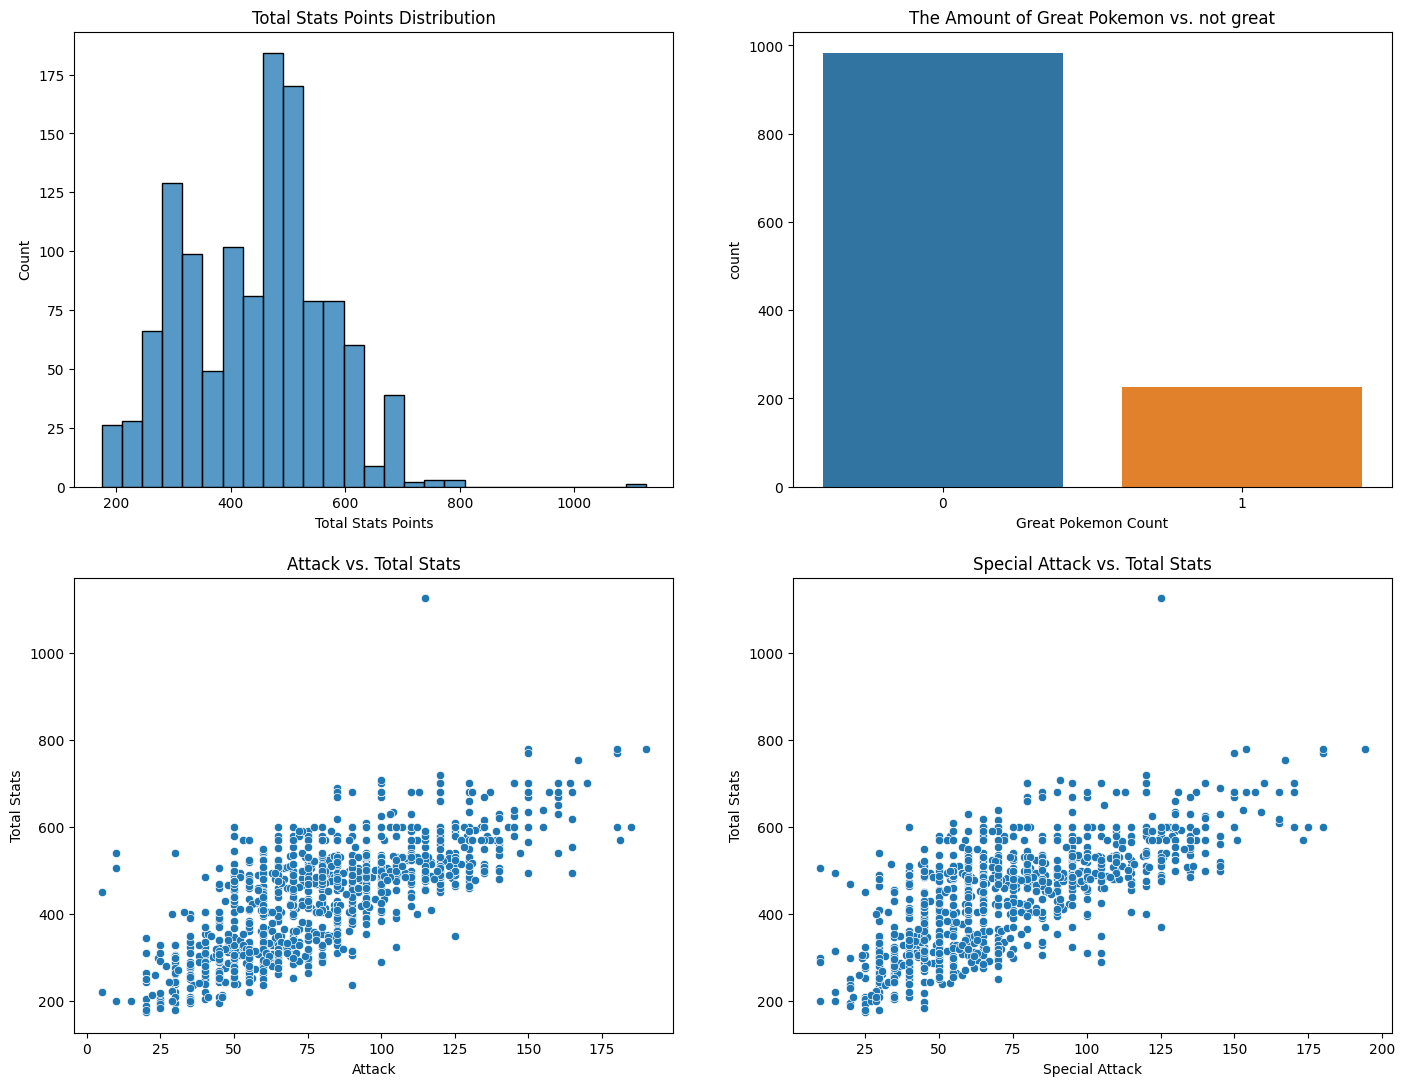

In [158]:
#Creating the figures and axes to place plots
fig, ax = plt.subplots(2,2,figsize=(17,13))

#Plotting the outcome varaible
sns.histplot(poke_df['Total'],ax=ax[0,0])

#Plotting binary outcome varaible
sns.countplot(x=poke_df['Great_Pokemon'], ax=ax[0,1]) #1 = great, 0 = not great

#Bivariate plots
#Plotting Attack vs. Total Stats
sns.scatterplot(x=poke_df['Attack'],y=poke_df['Total'],ax=ax[1,0])
#Plotting Defense vs. Total Stats
sns.scatterplot(x=poke_df['Special_Attack'],y=poke_df['Total'],ax=ax[1,1])

#Setting the labels and title
ax[0,0].set(xlabel='Total Stats Points',title='Total Stats Points Distribution')
ax[0,1].set(xlabel='Great Pokemon Count',title='The Amount of Great Pokemon vs. not great')
ax[1,0].set(xlabel='Attack', ylabel='Total Stats', title='Attack vs. Total Stats')
ax[1,1].set(xlabel='Special Attack', ylabel='Total Stats',title='Special Attack vs. Total Stats');


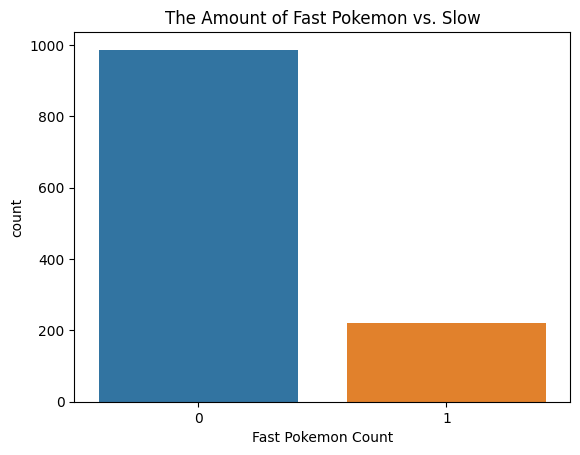

In [159]:
#Plotting Fast binary outcome varaible

sns.countplot(x=poke_df['Fast']).set(xlabel='Fast Pokemon Count',title='The Amount of Fast Pokemon vs. Slow'); 
#1 = fast, 0 = slow

### Linear Regression Model

Conducting a regression model where my predictor is "Attack" and my outcome of choice is "Total"

In [160]:
est_model = ols('Total~Attack', data=poke_df).fit()
est_model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,219.0191,6.467,33.865,0.000,206.330,231.708
Attack,2.7567,0.074,37.135,0.000,2.611,2.902


In [161]:
#Finding the Standard Deviation
np.sqrt(est_model.scale)

82.68638891148314

### Interpretations


#### Assumed model

$$
Y_i = \beta_0 + \beta_1 X_i + \epsilon_i
$$

Where $\epsilon_i$ are independent, normally distributed variables with $E(\epsilon_i)=0$ and $SD(\epsilon_i)=\sigma$.


#### Estimated model

$$
Y_i = 219.02 + 2.76 X_i + \epsilon_i
$$

Where $\epsilon_i$ are independent, normally distributed variables with $E(\epsilon_i)=0$ and $SD(\epsilon_i)$=82.69.

#### Checking the Assumptions

In order to check the assumptions that the residuals are independent, normally distributed variables where  $E(\epsilon_i)=0$ and $SD(\epsilon_i)$=82.69 I would have to perform model diagnosis. As the exam instructions do not explicitly state that I am required to do this, I will perform an example for this regression only.

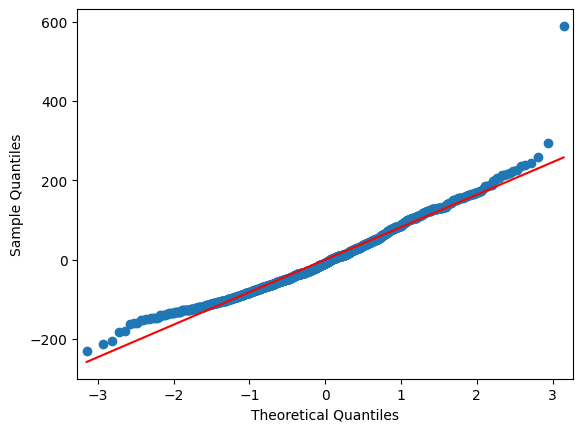

In [162]:
#In this plot I am checking if the estimated errors are normally distributed 
sm.qqplot(est_model.resid,line='r');

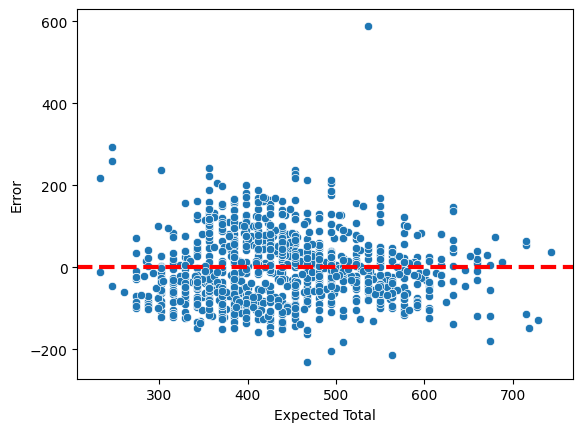

In [163]:
#Next, in this plot I will create a residual plot to see if the estimated errors have E(ei)=0 
#and if SD(ei) = 82.69.

ax = sns.scatterplot(x=est_model.predict(),y=est_model.resid)
ax.axhline(color='red',linestyle='--',linewidth=3)
ax.set(xlabel='Expected Total',ylabel='Error');

From these plots I can not assume that the residuals are normally distributed and I can not assume that  $E(\epsilon_i)=0$ and $SD(\epsilon_i)=82.69$. Because of this I would need to use robust confidence intervals.  


#### Interpretations of Coefficients

The estimated $\beta_0$ can be interpreted as the intercept, or what the Total is expected to be if Attack was 0. So if Attack was zero Total would be expected to be 219.02. 


The estimated $\beta_1$ can be interpreted as the 'effect' of one unit increase of Attack on expected Total. So for a one unit increase in Attack, Total is likely to increase by 2.76.

#### Interpretation of P-Values

General p-value Interpretation: The p-value can tell us if a coefficient is statistically significant or not. The p value is the probability that the null hypothesis is true. The null hypothesis tells us if there is no correlation, so to reject the null hypothesis would be to say that there is correlation and the data is significant. The null hypothesis would be rejected and the data is significant if p < 0.05. If p > 0.05 then the data is not statistically significant. 

The estimated $\beta_0$ 's p-value is 0.00 meaning it is statistically significant. 

The estimated $\beta_1$ 's p-value is 0.00 meaning it is statistically significant. 

#### Interpretation of Confidence Intervals  

General CI Interpretation: If the data is created by the assumed model, the CI shows the range of values that are consistent with the estimate. If the coefficient is between the CI, then we can assume the patterns in the data are likely. The CI can also determine if there is no statistical significance by checking if the CI crosses 0. If it does cross 0 then it is not significant.


The estimated $\beta_0$ CI = [206.330,231.708]. The estimated $\beta_0$ is within the CI and does not cross zero.

The estimated $\beta_1$ CI = [2.611,2.902] . The estimated $\beta_1$ is within the CI and does not cross zero.

### Logistic Regresstion 

Binary outcome variables is if the Pokemon is great or not, 'Great_Pokemon', and the predictor of
interest is the Attack score. 

In [164]:
est_model_2 = smf.logit('Great_Pokemon~Attack', data = poke_df).fit()
est_model_2.summary().tables[1]

Optimization terminated successfully.
         Current function value: 0.358585
         Iterations 7


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-5.7785,0.342,-16.893,0.000,-6.449,-5.108
Attack,0.0464,0.003,14.151,0.000,0.040,0.053


#### Interpretations

We can interpret this as that as the attack score increases so does the chance that the Pokemon is 'great'. The P value is both less than 0.05 which tells us that it is statistically significant. The coefficient is withing the CI and the CI does not cross 0.

### Linear Model with Control

The outcome variable is Total and the predictor is Attack with Special Attack as the control.

In [165]:
est_model_3 = ols('Total~Attack+Special_Attack', data=poke_df).fit()
est_model_3.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,128.0815,4.944,25.909,0.000,118.383,137.780
Attack,2.0903,0.053,39.629,0.000,1.987,2.194
Special_Attack,1.9807,0.052,38.405,0.000,1.880,2.082


In [166]:
#Finding the Standard Deviation
np.sqrt(est_model_3.scale)

55.48121553585879

### Interpretations


#### Assumed model

$$
Y_i = \beta_0 + \beta_1 X_{i,1} + \beta_2 X_{i,2} + \epsilon_i
$$


Where $\epsilon_i$ are independent, normally distributed variables with $E(\epsilon_i)=0$ and $SD(\epsilon_i)=\sigma$.

#### Estimated model

$$
Y_i = 128.08 + 2.09 X_{i,1} + 1.98 X_{i,2} + \epsilon_i
$$

Where $\epsilon_i$ are independent, normally distributed variables with $E(\epsilon_i)=0$ and $SD(\epsilon_i)$=55.48.

#### Interpretations of Coefficients

Effect of control: When there is no control the attack coefficient is 2.76. When I control for special attack, the attack coefficient decreases to 2.09.

The estimated $\beta_0$ = 128.08 (intercept). This represents the estimated value of the Total variable when all the predictors are 0. 
The p-value is 0.00, less than 0.05, meaning it is statistically significant. It is also within its CI of [118.383,137.780] and the CI does not cross 0. 

The estimated $\beta_1$ = 2.09 (Attack). For each one unit increase in Attack, Total is estimated to increase by  2.09 while holding Special Attack constant.
The p-value is 0.00, less than 0.05, meaning it is statistically significant. It is also within its CI of [1.987, 2.194] and the CI does not cross 0. 

The estimated $\beta_2$ = 1.98 (Special Attack). For each one unit increase in Special Attack, Total is estimated to increase by 1.98 while holding Attack constant. 
The p-value is 0.00, less than 0.05, meaning it is statistically significant. It is also within its CI of [1.880, 2.082] and the CI does not cross 0. 

### Linear Regression with Interaction Term

The expected outcome is Total and the interaction term is between Attack and Fast (binary variable noting if the Pokemon is considered fast)

In [167]:
est_model_4 = ols('Total~Attack*Fast', data=poke_df).fit()
est_model_4.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,208.7793,6.553,31.862,0.000,195.924,221.635
Attack,2.7240,0.079,34.480,0.000,2.569,2.879
Fast,183.2012,18.538,9.883,0.000,146.831,219.571
Attack:Fast,-1.1412,0.185,-6.170,0.000,-1.504,-0.778


In [168]:
#Finding the Standard Deviation
np.sqrt(est_model_4.scale)

76.68827551028073

### Interpretations

#### Assumed model

$$
Y_i = \beta_0 + \beta_1 X_{i,1} + \beta_2 X_{i,2} + \beta_3 X_{i,1} * X_{i,2}  + \epsilon_i
$$


Where $\epsilon_i$ are independent, normally distributed variables with $E(\epsilon_i)=0$ and $SD(\epsilon_i)=\sigma$.

#### Estimated model

$$
Y_i = 208.78 + 2.72 X_{i,1} + 183.20 X_{i,2} - 1.14 X_{i,1} * X_{i,2}  + \epsilon_i
$$


Where $\epsilon_i$ are independent, normally distributed variables with $E(\epsilon_i)=0$ and $SD(\epsilon_i)=76.69$.

#### Interpretations of Coefficients, P-Values, and CI

The estimated $\beta_0$ = 208.78 (intercept). This represents the estimated value of the Total variable when all the predictors are 0. 
The p-value is 0.00, less than 0.05, meaning it is statistically significant. It is also within its CI of [195.924,221.635] and the CI does not cross 0. 

The estimated $\beta_1$ = 2.72 (Attack). This is the relationship between Attack and Total when Fast is 0. The p value is 0.0 showing statistical significance. Its within the CI of [2.569,2.879] and the CI does not cross 0. 

The estimated $\beta_2$ = 183.20 (Fast). This is the relationship between Fast and Total when Attack is 0. The p value is 0.0 showing statistical significance. Its within the CI of [146.831,219.571] and the CI does not cross 0. 

Attack:Fast(Interaction term) = -1.14. The interaction term tells us the size of the relationship between Attack and Total depending on whether the Pokemon is 'fast' or 'slow'. When the Pokemon is 'fast', Attack has a weaker effect on Total. The p-value is 0.000 which tells us that there is a conditional relationship. The coefficient is within its CI of [-1.504,-0.778] and the CI does not cross 0. 
 

### Logistic Regression Model for any Outcome of Interest  with a Non-Binary Categorical Variable as the Predictor

The outcome of interest is Great_Pokemon, which tells us if a Pokemon is considered great or not, and Type categorical variable is the predictor. 

In [169]:
est_model_5 = smf.logit('Great_Pokemon~C(Type)', data=poke_df).fit()
est_model_5.summary().tables[1]


Optimization terminated successfully.
         Current function value: 0.449340
         Iterations 6


,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-2.3394,0.370,-6.319,0.000,-3.065,-1.614
C(Type)[T.Dark],1.2408,0.482,2.574,0.010,0.296,2.185
C(Type)[T.Dragon],2.4620,0.468,5.261,0.000,1.545,3.379
C(Type)[T.Electric],0.8841,0.474,1.863,0.062,-0.046,1.814
C(Type)[T.Fairy],1.4456,0.542,2.668,0.008,0.384,2.508
C(Type)[T.Fighting],0.8231,0.522,1.577,0.115,-0.200,1.846
C(Type)[T.Fire],1.0176,0.465,2.189,0.029,0.106,1.929
C(Type)[T.Flying],0.9531,0.873,1.092,0.275,-0.758,2.664
C(Type)[T.Ghost],0.4176,0.573,0.729,0.466,-0.705,1.540
C(Type)[T.Grass],0.2393,0.480,0.498,0.618,-0.702,1.180


#### Interpretation of Coefficients

From this we can determine that all the types increase the likelihood that a Pokemon is great. 

However, only dark, dragon, fairy, fire, psychic, and steel are statistically significant (p<0.05). All the CIs also show the data is not significant, meaning they cross through 0, except for dark, dragon, fairy, fire, psychic and steel. 

### Squared Term or Log Outcome? 

When I investigate the scatter plots of the attack and special attack variables, it seems as though the relationship is linear. From this I would determine that I would not use a squared term. 

When examining the total stats distribution plot, the plot is not skewed so I would not log the outcome variable. I also would not log the predictor Attack because the distribution is not skewed. I potentially could log the special attack predictor because it looks as though the distribution is slightly skewed.     



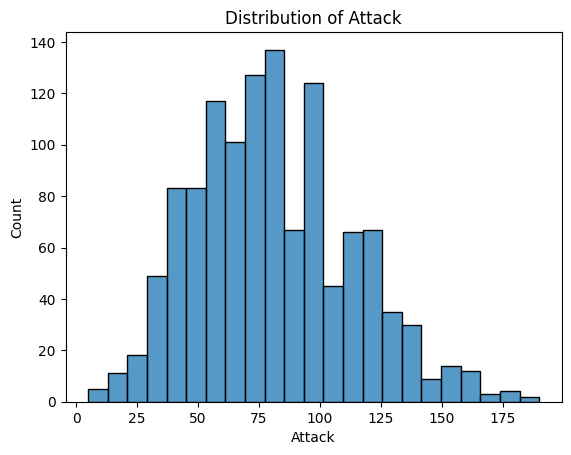

In [170]:
sns.histplot(poke_df['Attack']).set(xlabel='Attack',title='Distribution of Attack');

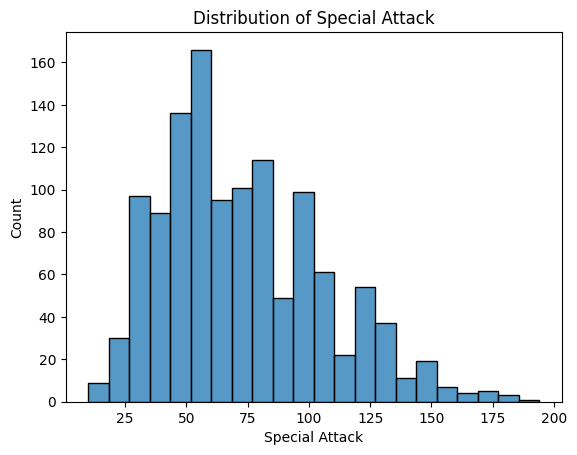

In [171]:
sns.histplot(poke_df['Special_Attack']).set(xlabel='Special Attack',title='Distribution of Special Attack');